In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
import joblib 
import os

In [2]:
data = pd.read_csv("1 Delinquency_prediction_dataset.csv")

In [3]:
pd.set_option('display.expand_frame_repr', True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)

## EDA and Cleaning of Data

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    str    
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    str    
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    str    
 12  Location              500 non-null    str    
 13  Month_1               500 non-null    str    
 14  Month_2               500 non-null    str    
 15  Month_3               500 non-null

In [5]:
print(data.describe())

              Age         Income  Credit_Score  Credit_Utilization  Missed_Payments  Delinquent_Account  Loan_Balance  Debt_to_Income_Ratio  Account_Tenure
count  500.000000     461.000000    498.000000          500.000000       500.000000          500.000000    471.000000            500.000000      500.000000
mean    46.266000  108379.893709    577.716867            0.491446         2.968000            0.160000  48654.428875              0.298862        9.740000
std     16.187629   53662.723741    168.881211            0.197103         1.946935            0.366973  29395.537273              0.094521        5.923054
min     18.000000   15404.000000    301.000000            0.050000         0.000000            0.000000    612.000000              0.100000        0.000000
25%     33.000000   62295.000000    418.250000            0.356486         1.000000            0.000000  23716.500000              0.233639        5.000000
50%     46.500000  107658.000000    586.000000            0.4856

##### Creating Copy a copy of original data

In [6]:
df = data.copy()

##### Visualizing the distribution of numerical features

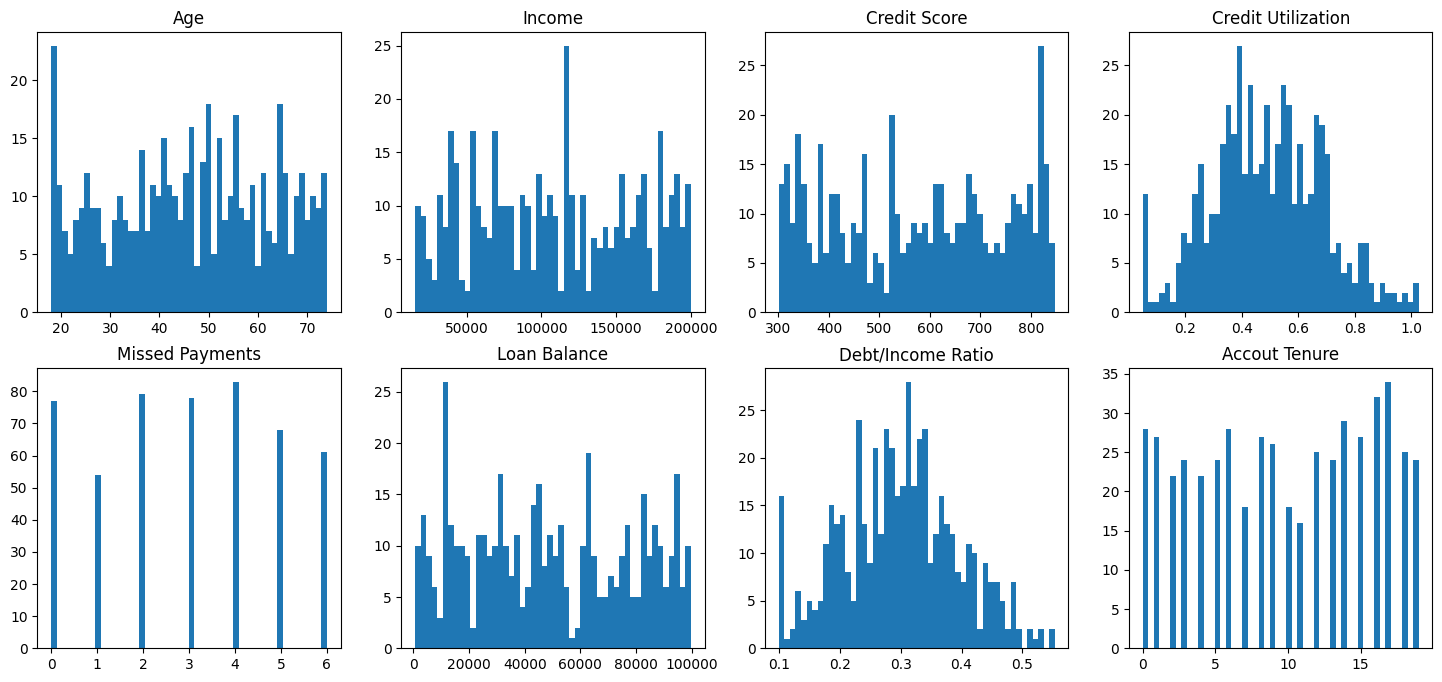

In [7]:
plt.figure(figsize=(18,8))
plt.subplot(2,4,1)
# plt.subplots_adjust(hspace=0.5)
plt.hist(df['Age'], bins=50)
plt.title('Age')
plt.subplot(2,4,2)
plt.hist(df['Income'], bins=50)
plt.title('Income')
plt.subplot(2,4,3)
plt.hist(df['Credit_Score'], bins=50)
plt.title('Credit Score')
plt.subplot(2,4,4)
plt.hist(df['Credit_Utilization'], bins=50)
plt.title('Credit Utilization')
plt.subplot(2,4,5)
plt.hist(df['Missed_Payments'], bins=50)
plt.title('Missed Payments')
plt.subplot(2,4,6)
plt.hist(df['Loan_Balance'], bins=50)
plt.title('Loan Balance')
plt.subplot(2,4,7)
plt.hist(df['Debt_to_Income_Ratio'], bins=50)
plt.title('Debt/Income Ratio')
plt.subplot(2,4,8)
plt.hist(df['Account_Tenure'], bins=50)
plt.title('Accout Tenure')
plt.show()

##### Tackeling null or missing values.

In [8]:
df['Credit_Score'] = df['Credit_Score'].fillna(df['Credit_Score'].median())

In [9]:
# Creating a feature to tag the null values in the Income feature before filling the null values

df['Income_Missing_Flag'] = df['Income'].isnull().astype(int)

In [10]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [11]:
# Checking if there is any pattern in missing values?

print(df[df['Loan_Balance'].isnull()])

    Customer_ID  Age    Income  Credit_Score  Credit_Utilization  Missed_Payments  Delinquent_Account  Loan_Balance  Debt_to_Income_Ratio Employment_Status  Account_Tenure Credit_Card_Type     Location  Month_1  Month_2  Month_3  Month_4  Month_5  Month_6  Income_Missing_Flag
8      CUST0009   36   66991.0         405.0            0.413035                5                   1           NaN              0.219854          Employed              12          Student      Phoenix  On-time  On-time  On-time   Missed     Late  On-time                    0
23     CUST0024   47  108468.0         538.0            0.816191                2                   1           NaN              0.317053           retired               7             Gold      Phoenix     Late     Late     Late  On-time     Late     Late                    0
25     CUST0026   19  193998.0         515.0            0.255552                5                   0           NaN              0.259893               EMP              

In [12]:
# Creating a feature to tag the null values in the Loan balance provided feature before filling the null values

df['Loan_Balance_Missing_Flag'] = df['Loan_Balance'].isnull().astype(int)

In [13]:
df['Loan_Balance'] = df['Loan_Balance'].fillna(df['Loan_Balance'].median())

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_ID                500 non-null    str    
 1   Age                        500 non-null    int64  
 2   Income                     500 non-null    float64
 3   Credit_Score               500 non-null    float64
 4   Credit_Utilization         500 non-null    float64
 5   Missed_Payments            500 non-null    int64  
 6   Delinquent_Account         500 non-null    int64  
 7   Loan_Balance               500 non-null    float64
 8   Debt_to_Income_Ratio       500 non-null    float64
 9   Employment_Status          500 non-null    str    
 10  Account_Tenure             500 non-null    int64  
 11  Credit_Card_Type           500 non-null    str    
 12  Location                   500 non-null    str    
 13  Month_1                    500 non-null    str    
 14  Month

##### Checking for duplicate rows

In [15]:
df.duplicated().sum()

np.int64(0)

##### Visualizing the outliers using boxplots

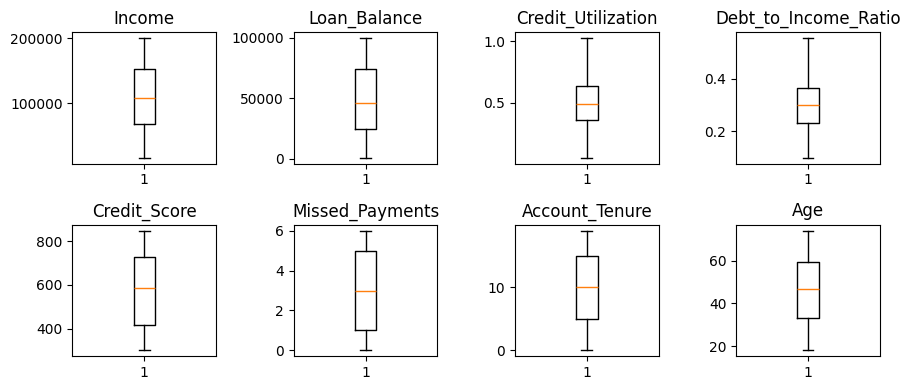

In [16]:
plt.figure(figsize=(9,4))

plt.subplot(2,4,1)
plt.boxplot(df['Income'])
plt.title('Income')

plt.subplot(2,4,2)
plt.boxplot(df['Loan_Balance'])
plt.title('Loan_Balance')

plt.subplot(2,4,3)
plt.boxplot(df['Credit_Utilization'])
plt.title('Credit_Utilization')

plt.subplot(2,4,4)
plt.boxplot(df['Debt_to_Income_Ratio'])
plt.title('Debt_to_Income_Ratio')

plt.subplot(2,4,5)
plt.boxplot(df['Credit_Score'])
plt.title('Credit_Score')

plt.subplot(2,4,6)
plt.boxplot(df['Missed_Payments'])
plt.title('Missed_Payments')

plt.subplot(2,4,7)
plt.boxplot(df['Account_Tenure'])
plt.title('Account_Tenure')

plt.subplot(2,4,8)
plt.boxplot(df['Age'])
plt.title('Age')

plt.tight_layout()

plt.show()

##### Checking class imbalance.

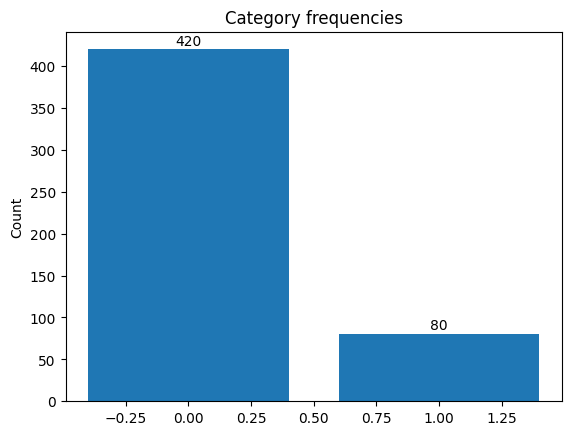

In [17]:
counts = pd.Series(df['Delinquent_Account']).value_counts()
bar = plt.bar(counts.index, counts.values)
plt.bar_label(bar, padding=1)
plt.ylabel('Count')
plt.title('Category frequencies')
plt.show()

#### Handelling Categorical columns and correcting data types.

In [18]:
mapping = {'Late':0, 'Missed':1, 'On-time':2}
cols = ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']

df[cols] = df[cols].replace(mapping)

In [19]:
df = df.astype({'Month_1': 'int', 'Month_2': 'int', 'Month_3': 'int', 'Month_4': 'int', 'Month_5': 'int', 'Month_6': 'int'})

#### Feature Engineering

In [20]:
df['Missed_Payments_6_months'] = df[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']].eq(1).sum(axis=1)

df['Late_Payments_6_months'] = df[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']].eq(0).sum(axis=1)

df['Trend_Score'] = df['Month_1']*5 + df['Month_4']*1 + df['Month_6']*3

In [21]:
# Creating a feature to count the number of instances where user missed >2 payments in a row for analysing recent behaviour of the user.

from itertools import groupby

cols = [f"Month_{i}" for i in range(1, 7)]

def count_consecutive_missed(row):
    """Count instances where user missed >2 payments in a row"""
    values = row[cols].tolist()
    
    # Group consecutive values
    consecutive_groups = [(key, len(list(group))) for key, group in groupby(values)]
    
    # Count groups where value is 1 (missed) and length > 2
    count = sum(1 for key, length in consecutive_groups if key == 1 and length > 2)
    
    return count

# Apply the function to each row
df["consecutive_missed_gt2"] = df.apply(count_consecutive_missed, axis=1)

In [22]:
df['Stress_index'] = df['Credit_Utilization']*df['Debt_to_Income_Ratio']

In [23]:
df['Loan_Balance_to_income'] = df['Loan_Balance'] / df['Income']

In [24]:
df['Missed_to_Tenure_Ratio'] = df['Missed_Payments'] / (df['Account_Tenure']+1)

In [25]:
df['High_Utilization'] = (df['Credit_Utilization'] > 0.8).astype(int)
df['High_DTI'] = (df['Debt_to_Income_Ratio'] > 0.4).astype(int)
df['Low_Credit_Score'] = (df['Credit_Score'] < 600).astype(int)

In [26]:
print(df['Missed_to_Tenure_Ratio'])

0      0.157895
1      6.000000
2      0.000000
3      0.187500
4      0.166667
         ...   
495    0.200000
496    0.105263
497    0.000000
498    0.166667
499    1.000000
Name: Missed_to_Tenure_Ratio, Length: 500, dtype: float64


##### Saving the preprocessed and feature engineered data

In [27]:
# df.to_csv('Data_preprocessed_df', index=False)

In [28]:
df_preprocessed = pd.read_csv('Data_preprocessed_df')

In [29]:
correlations = df_preprocessed.drop(columns=['Delinquent_Account']).corrwith(df_preprocessed['Delinquent_Account'], numeric_only=True)

print(correlations)

Age                          0.022508
Income                       0.043991
Credit_Score                 0.034733
Credit_Utilization           0.034224
Missed_Payments             -0.026478
Loan_Balance                -0.005438
Debt_to_Income_Ratio         0.034386
Account_Tenure              -0.039829
Month_1                      0.094059
Month_2                      0.027288
Month_3                      0.013270
Month_4                     -0.089307
Month_5                     -0.032834
Month_6                      0.053047
Income_Missing_Flag         -0.025225
Loan_Balance_Missing_Flag    0.055081
Missed_Payments_6_months    -0.001367
Late_Payments_6_months      -0.024006
Trend_Score                  0.091332
consecutive_missed_gt2      -0.002884
Stress_index                 0.048682
Loan_Balance_to_income      -0.039343
Missed_to_Tenure_Ratio       0.086870
High_Utilization            -0.006152
High_DTI                     0.033184
Low_Credit_Score            -0.061150
dtype: float

In [30]:
df_key_attributes = df_preprocessed[['Delinquent_Account', 'Month_1', 'Month_4', 'Month_6', 'Loan_Balance_Missing_Flag', 'Trend_Score', 'Missed_to_Tenure_Ratio', 'Low_Credit_Score']]

#### Bivariate Analysis

In [31]:
bivariate_stats = df_preprocessed.groupby('Delinquent_Account')[['Age', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments', 'Debt_to_Income_Ratio', 'Account_Tenure', 'Income', 'Loan_Balance']].agg(['mean', 'median'])

print(bivariate_stats.to_string())

# bivariate_stats.to_excel('bivariate_stats.xlsx', sheet_name='Data')

                          Age        Credit_Score        Credit_Utilization           Missed_Payments        Debt_to_Income_Ratio           Account_Tenure                Income            Loan_Balance         
                         mean median         mean median               mean    median            mean median                 mean    median           mean median           mean    median          mean   median
Delinquent_Account                                                                                                                                                                                               
0                   46.107143   46.0   575.197619  584.0           0.488505  0.483751        2.990476    3.0             0.297445  0.301634       9.842857   10.0  107335.361905  107658.0  48555.135714  45776.0
1                   47.100000   50.0   591.150000  625.0           0.506887  0.493021        2.850000    3.0             0.306301  0.303280       9.200000    9.

#### Data Scaling and then Training the model

#### Model 1 : Training Logistic Regression

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [33]:
x, y = df_key_attributes.drop('Delinquent_Account', axis=1), df_key_attributes['Delinquent_Account']

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42, stratify=y)

In [44]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model = LogisticRegression(class_weight='balanced', max_iter=300, random_state=42)

In [46]:
model.fit(x_train, y_train)
predictions = model.predict(x_test)
probabilities = model.predict_proba(x_test)[:, 1]
print(probabilities)

[0.29330344 0.43467736 0.71795285 0.49920858 0.65901983 0.40266109
 0.53171518 0.22350693 0.62575602 0.61830493 0.45050458 0.72451192
 0.36357196 0.3944146  0.39051595 0.39864501 0.31057569 0.48611467
 0.52904711 0.46148239 0.44403728 0.39106767 0.49194552 0.59182184
 0.66912637 0.74854231 0.5465981  0.76202794 0.45855094 0.48021226
 0.53848497 0.38884385 0.26331748 0.47055515 0.59380034 0.57764727
 0.32934241 0.47966139 0.5061685  0.63905539 0.52904711 0.38834055
 0.74318308 0.19107131 0.66375621 0.30430748 0.83086572 0.37502581
 0.45682475 0.37438699]


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, roc_auc_score

accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy : {accuracy}')

precision = precision_score(y_test, predictions)
print(f'Precision : {precision}')

recall = recall_score(y_test, predictions)
print(f'Recall : {recall}')

roc_auc = roc_auc_score(y_test, probabilities)
print(f'ROC AUC Score: {roc_auc}')

Accuracy : 0.58
Precision : 0.19047619047619047
Recall : 0.5
ROC AUC Score: 0.5535714285714286


In [48]:
thresholds = [0.5, 0.49, 0.48, 0.47, 0.46, 0.45] #0.49

for t in thresholds:
    y_pred_custom = (probabilities >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print('roc_auc_score:', roc_auc_score(y_test, y_pred_custom))
    print("Accuracy:", accuracy_score(y_test, y_pred_custom))
    print("Precision:", precision_score(y_test, y_pred_custom))
    print("Recall:", recall_score(y_test, y_pred_custom))


Threshold: 0.5
roc_auc_score: 0.5476190476190476
Accuracy: 0.58
Precision: 0.19047619047619047
Recall: 0.5

Threshold: 0.49
roc_auc_score: 0.5238095238095238
Accuracy: 0.54
Precision: 0.17391304347826086
Recall: 0.5

Threshold: 0.48
roc_auc_score: 0.5
Accuracy: 0.5
Precision: 0.16
Recall: 0.5

Threshold: 0.47
roc_auc_score: 0.47619047619047616
Accuracy: 0.46
Precision: 0.14814814814814814
Recall: 0.5

Threshold: 0.46
roc_auc_score: 0.4642857142857143
Accuracy: 0.44
Precision: 0.14285714285714285
Recall: 0.5

Threshold: 0.45
roc_auc_score: 0.4285714285714285
Accuracy: 0.38
Precision: 0.12903225806451613
Recall: 0.5


In [49]:
conf_ma = confusion_matrix(y_test, predictions)
print(conf_ma) 

[[25 17]
 [ 4  4]]


In [50]:
def metrices(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred)
    
    return accuracy, precision, recall, roc_auc

In [51]:
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'roc_auc': 'roc_auc'
}

cv_results = cross_validate(model, x_train, y_train, cv=5, scoring=scoring, return_train_score=False)

# print mean +/- std for each metric
for metric in scoring:
    print(metric, cv_results[f'test_{metric}'].mean(), cv_results[f'test_{metric}'].std())

accuracy 0.6244444444444445 0.04000000000000001
precision 0.23615358934271385 0.04861660330300589
recall 0.6076190476190476 0.14545573077232973
roc_auc 0.6162069340016708 0.08861672241939794


##### Saving The Model

In [52]:
import joblib
joblib.dump(model, 'logistic_regression_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(df_key_attributes.columns, 'model_features.pkl')

['model_features.pkl']

In [3]:
model_ = joblib.load('logistic_regression_model.pkl')
scaler_ = joblib.load('scaler.pkl')
model_features_ = joblib.load('model_features.pkl')
model_features_

Index(['Delinquent_Account', 'Month_1', 'Month_4', 'Month_6',
       'Loan_Balance_Missing_Flag', 'Trend_Score', 'Missed_to_Tenure_Ratio',
       'Low_Credit_Score'],
      dtype='str')

In [54]:
model_.predict(x_test)

array([0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 0])

#### Phase 7: Explainability

Convert logistic regression coefficients to odds ratios and interpret them.

In [5]:
import numpy as np

# Load the model and features
model = joblib.load('logistic_regression_model.pkl')
features = joblib.load('model_features.pkl')[1:]  # Exclude the target column

# Get coefficients
coefficients = model.coef_[0]

# Calculate odds ratios
odds_ratios = np.exp(coefficients)

# Create a DataFrame for interpretation
import pandas as pd
interpretation_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
    'Odds_Ratio': odds_ratios
})

print(interpretation_df)

# Interpretation
for idx, row in interpretation_df.iterrows():
    feature = row['Feature']
    or_val = row['Odds_Ratio']
    if or_val > 1:
        print(f"A one standard deviation increase in {feature} increases the odds of delinquency by {or_val:.2f} times.")
    elif or_val < 1:
        print(f"A one standard deviation increase in {feature} decreases the odds of delinquency by {1/or_val:.2f} times.")
    else:
        print(f"{feature} has no effect on the odds of delinquency.")

                     Feature  Coefficient  Odds_Ratio
0                    Month_1     0.182267    1.199934
1                    Month_4    -0.348882    0.705476
2                    Month_6     0.091992    1.096357
3  Loan_Balance_Missing_Flag     0.175639    1.192007
4                Trend_Score     0.140962    1.151381
5     Missed_to_Tenure_Ratio     0.203994    1.226291
6           Low_Credit_Score    -0.200898    0.817996
A one standard deviation increase in Month_1 increases the odds of delinquency by 1.20 times.
A one standard deviation increase in Month_4 decreases the odds of delinquency by 1.42 times.
A one standard deviation increase in Month_6 increases the odds of delinquency by 1.10 times.
A one standard deviation increase in Loan_Balance_Missing_Flag increases the odds of delinquency by 1.19 times.
A one standard deviation increase in Trend_Score increases the odds of delinquency by 1.15 times.
A one standard deviation increase in Missed_to_Tenure_Ratio increases the od